In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

import logging
import time

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from venti.unwrap.unwrap_corrections import UnwrapCorrector

logging.getLogger("venti").setLevel(logging.WARNING)
plt.rcParams["figure.dpi"] = 90
print("repo:", REPO)
print("golden:", GOLDEN, GOLDEN.exists())
print("scratch:", SCRATCH)

repo: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/.claude/worktrees/agent-a5eeaf609fe7a404d
golden: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden True
scratch: /u/aurora-r0/govorcin/tmp/cal_disp_notebooks


# 01 — Unwrapping-error correction: the cycle is λ/2, not λ

**Defect.** `src/cal_disp/workflow.py:602-606` and `:627` at commit `dcce716` (the state before the fix;
`run_calibration`, the `wavelength_m=` argument of `venti.surface.estimate_calibration_surface`) handed
Venti the full radar wavelength read from `/identification/radar_wavelength` (0.05547 m for Sentinel-1).
Venti's `UnwrapCorrector` (`venti/unwrap/unwrap_corrections.py`, `_compute_unwrap_cycles`) rounds the
median offset of every region to an integer number of that value:
`cycles = round(offsets / wavelength)`.

For repeat-pass InSAR the radar wave travels the path **twice**, so one phase cycle (2π) is
**λ/2 = 27.7 mm** of line-of-sight displacement, not λ = 55.5 mm. With λ as the cycle:

* a genuine one-cycle unwrapping error (27.7 mm) is `round(0.5)` cycles → 0, i.e. it is **not** corrected
  (or, with a little real signal on top, becomes a 55.5 mm "correction" that leaves a −27.7 mm error);
* a real offset of 40-80 mm between two regions is "corrected" by 55.5 mm.

**Fix.** `workflow.py` now passes `unwrap_cycle_m = _unwrap_cycle_length_m(wavelength) = λ / 2`
(derived from the product wavelength, so NISAR L-band products get their own λ/2).

**Why the correction is now off by default** (`CalibrationOptions.unwrap_error_correction = False` in
`src/cal_disp/config/_algorithm.py`; it was `True` at `:116-117`). Venti does not segment the field at phase discontinuities: it runs a
watershed on the Sobel edges of the *valid mask*, i.e. its "regions" are the connected components of the
mask (islands between masked rivers, water, decorrelated areas). Every island is then compared with the
first island (top-left) and shifted by whole cycles. On the golden frame the offsets between islands are
mostly larger than half a cycle and continuously distributed, so the correction turns long-wavelength
signal - what the calibration is meant to fit - into whole-cycle steps. With the correct, smaller cycle
even more islands are shifted.

**This notebook** shows
1. on a synthetic field with a known one-cycle error: Venti's result with cycle = λ (wrong) vs λ/2 (right),
   and what happens to an island that carries a genuine offset;
2. on the real golden displacement (F08882): how many mask islands are shifted with the old and the new
   cycle length, and the histogram of the island offsets;
3. two full-frame `cal-disp run`s (correction on with λ/2, and off = new default) and the difference in the
   `calibration` layer.

## 1. Synthetic field with a known one-cycle error

Four mask islands (Venti's "regions"), all on one smooth field with ±5 mm of real signal:

* **A** (top-left): reference island (Venti compares everything with the first label).
* **B** (top-right) and **C** (bottom-left): a **+1 cycle (λ/2 = 27.7 mm)** unwrapping error is added; B sits
  on +3 mm and C on −3 mm of real signal relative to A.
* **D** (bottom-right): no unwrapping error but a **genuine +40 mm** offset (e.g. a subsidence bowl).

In [2]:
LAMBDA = 0.05546576          # Sentinel-1 radar wavelength (m), as stored in the DISP product
CYCLE = LAMBDA / 2           # LOS displacement of one 2π phase cycle (two-way path)
print(f"wavelength = {LAMBDA*1e3:.2f} mm, one unwrapping cycle = {CYCLE*1e3:.2f} mm")

ny, nx = 300, 300
yy, xx = np.mgrid[0:ny, 0:nx]
rng = np.random.default_rng(1)
# smooth real signal, ±4 mm, plus a small ramp; islands B/C get +/-3 mm w.r.t. A, D a genuine +40 mm
truth = 0.004 * np.sin(2 * np.pi * xx / nx) * np.cos(np.pi * yy / ny) + 1.0e-5 * xx
mask = np.ones((ny, nx), dtype=bool)
mask[145:155, :] = False      # horizontal masked strip -> two rows of islands
mask[:, 145:155] = False      # vertical masked strip   -> four islands
islands = {"A": (slice(0, 145), slice(0, 145)), "B": (slice(0, 145), slice(155, None)),
           "C": (slice(155, None), slice(0, 145)), "D": (slice(155, None), slice(155, None))}
mean_a = truth[islands["A"]].mean()
for isl, offset in [("B", 0.003), ("C", -0.003), ("D", 0.040)]:
    truth[islands[isl]] += offset + mean_a - truth[islands[isl]].mean()

unwrap_error = np.zeros((ny, nx), dtype=np.float32)
unwrap_error[islands["B"]] = CYCLE       # +1 cycle
unwrap_error[islands["C"]] = CYCLE       # +1 cycle
observed = (truth + unwrap_error + rng.normal(0, 0.0015, (ny, nx))).astype(np.float32)
observed_masked = np.where(mask, observed, np.nan).astype(np.float32)

def run_corrector(field, valid, cycle_m):
    corr = UnwrapCorrector(wavelength=cycle_m)
    out = np.ma.filled(np.ma.asarray(corr.correct(field, valid), dtype=np.float32), np.nan)
    return out, corr.get_region_info()

results = {}
for name, cyc in [("cycle = λ (old)", LAMBDA), ("cycle = λ/2 (fixed)", CYCLE)]:
    corrected, info = run_corrector(observed_masked, mask, cyc)
    results[name] = corrected
    print(f"\n{name}: {info['n_regions']} regions (A, B, C, D), shifts = {info['unwrap_cycles']} cycles"
          f" = {np.round(info['unwrap_cycles'] * cyc * 1e3, 1)} mm")
    for isl, sl in islands.items():
        resid = corrected[sl] - truth[sl]
        print(f"   island {isl}: median residual vs truth = {np.nanmedian(resid)*1e3:+6.1f} mm")

wavelength = 55.47 mm, one unwrapping cycle = 27.73 mm



cycle = λ (old): 4 regions (A, B, C, D), shifts = [0 1 0 1] cycles = [ 0.  55.5  0.  55.5] mm
   island A: median residual vs truth =   -0.0 mm
   island B: median residual vs truth =  -27.8 mm
   island C: median residual vs truth =  +27.7 mm
   island D: median residual vs truth =  -55.5 mm

cycle = λ/2 (fixed): 4 regions (A, B, C, D), shifts = [0 1 1 1] cycles = [ 0.  27.7 27.7 27.7] mm
   island A: median residual vs truth =   -0.0 mm
   island B: median residual vs truth =   -0.0 mm
   island C: median residual vs truth =   -0.0 mm
   island D: median residual vs truth =  -27.7 mm


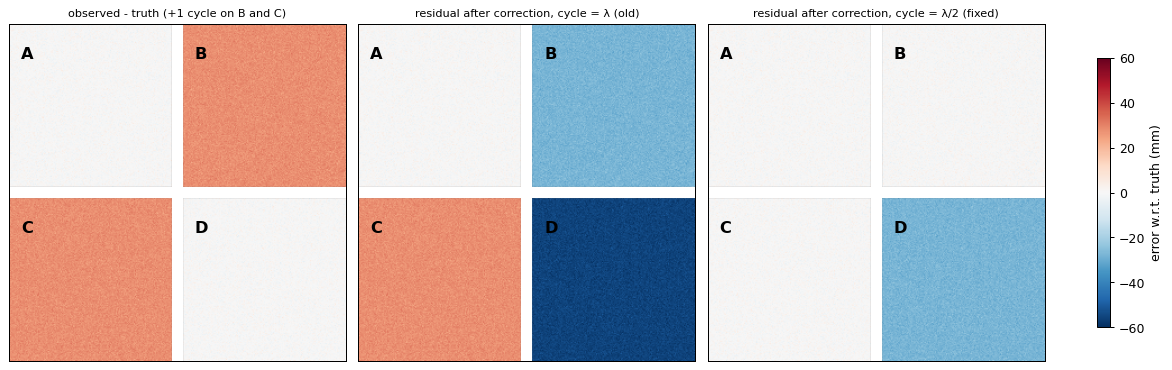

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
panels = [("observed - truth (+1 cycle on B and C)", observed_masked - truth),
          ("residual after correction, cycle = λ (old)", results["cycle = λ (old)"] - truth),
          ("residual after correction, cycle = λ/2 (fixed)", results["cycle = λ/2 (fixed)"] - truth)]
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(np.where(mask, img, np.nan) * 1e3, cmap="RdBu_r", vmin=-60, vmax=60)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    for isl, sl in islands.items():
        ax.text((sl[1].start or 0) + 10, (sl[0].start or 0) + 30, isl, fontsize=13, weight="bold")
fig.colorbar(im, ax=axes, shrink=0.8, label="error w.r.t. truth (mm)")
plt.show()

With the old cycle the one-cycle errors are either left in place (C: offset 24.7 mm, `round(24.7 / 55.5) = 0`
→ +27.7 mm error remains) or over-corrected by a whole wavelength (B: offset 30.7 mm, `round(30.7 / 55.5) = 1`
→ 27.7 − 55.5 = −27.7 mm error). With λ/2 both are fixed.

Island D never had an unwrapping error, yet it is "corrected" in both cases (by 55.5 mm with λ, by 27.7 mm
with λ/2): the corrector cannot tell a genuine inter-island offset from an unwrapping error because its
regions are mask islands, not phase-discontinuity regions. That is why the option is off by default.

## 2. Real golden displacement (frame F08882): how many islands get shifted?

`UnwrapCorrector` is run exactly as Venti does inside `estimate_calibration_surface`
(`correct_region_offset(disp, mask, wavelength)` at full resolution, valid mask = finite &
`recommended_mask` & `water_mask`).

In [4]:
disp_file = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
t0 = time.time()
with xr.open_dataset(disp_file, engine="h5netcdf", cache=False) as ds:
    disp = ds.displacement.values.astype(np.float32)
    valid = np.isfinite(disp)
    if "recommended_mask" in ds:
        valid &= ds.recommended_mask.values.astype(bool)
    if "water_mask" in ds:
        valid &= ds.water_mask.values.astype(bool)
disp_masked = np.where(valid, disp, np.nan).astype(np.float32)
del disp
print(f"{disp_file.name}\n  shape {disp_masked.shape}, valid pixels {valid.sum():,} ({valid.mean()*100:.1f}%),"
      f" loaded in {time.time()-t0:.1f} s")

real = {}
for name, cyc in [("λ (old)", LAMBDA), ("λ/2 (fixed)", CYCLE)]:
    t0 = time.time()
    _, info = run_corrector(disp_masked, valid, cyc)
    offsets_m = info["medians"] - info["medians"][0]         # island median offset w.r.t. first island
    cycles = info["unwrap_cycles"]
    shift_lut = np.zeros(info["labeled_regions"].max() + 1, dtype=np.float32)
    shift_lut[info["valid_labels"]] = cycles * cyc
    real[name] = {"offsets_mm": offsets_m * 1e3, "cycles": cycles, "cycle_mm": cyc * 1e3,
                  "shift_field_mm": shift_lut[info["labeled_regions"][::8, ::8]] * 1e3,
                  "n_regions": info["n_regions"]}
    n_shift = int(np.count_nonzero(cycles))
    print(f"cycle = {name:12s}: {info['n_regions']} mask islands, {n_shift} shifted"
          f" ({100*n_shift/info['n_regions']:.0f}%), max |shift| = {np.abs(cycles).max()} cycles"
          f" = {np.abs(cycles).max()*cyc*1e3:.0f} mm   [{time.time()-t0:.0f} s]")
labels_dec = info["labeled_regions"][::8, ::8]
off = real["λ (old)"]["offsets_mm"]
print(f"\nisland offsets w.r.t. first island: median {np.nanmedian(off):+.1f} mm,"
      f" 5-95% [{np.nanpercentile(off, 5):+.1f}, {np.nanpercentile(off, 95):+.1f}] mm;"
      f" |offset| > λ/4 = {CYCLE/2*1e3:.1f} mm (shifted with the fixed cycle): {(np.abs(off) > CYCLE/2*1e3).sum()}")

OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
  shape (7733, 9464), valid pixels 26,643,627 (36.4%), loaded in 8.7 s


cycle = λ (old)     : 6733 mask islands, 5752 shifted (85%), max |shift| = 3 cycles = 166 mm   [37 s]


cycle = λ/2 (fixed) : 6733 mask islands, 6182 shifted (92%), max |shift| = 6 cycles = 166 mm   [35 s]

island offsets w.r.t. first island: median +78.4 mm, 5-95% [+4.3, +123.8] mm; |offset| > λ/4 = 13.9 mm (shifted with the fixed cycle): 6182


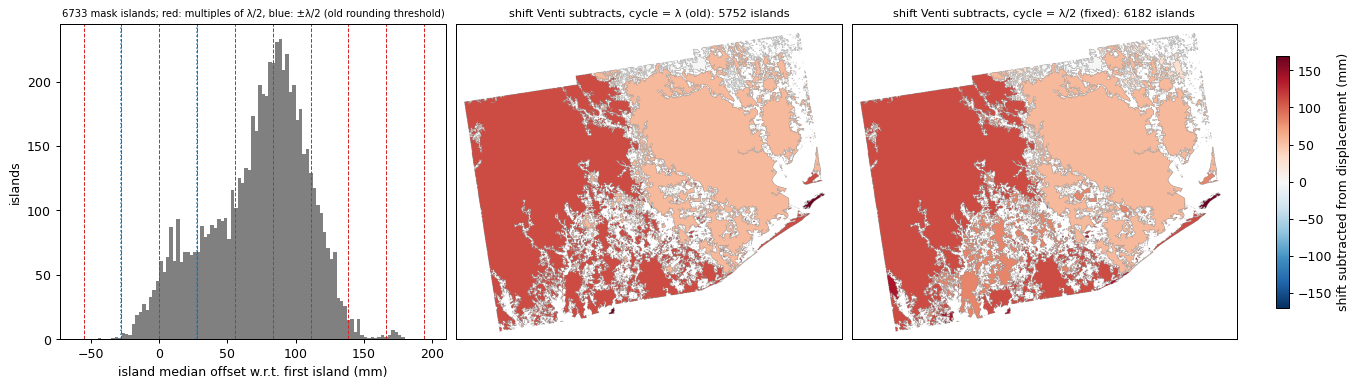

cycle = λ (old)     : islands per shift (mm): -55: 5, +0: 981, +55: 2773, +111: 2888, +166: 86
cycle = λ/2 (fixed) : islands per shift (mm): -55: 1, -28: 55, +0: 551, +28: 830, +55: 1253, +83: 2254, +111: 1477, +139: 280, +166: 32


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
ax = axes[0]
ax.hist(off, bins=np.arange(-60, 200, 2.5), color="0.5")
for k in range(-2, 8):
    ax.axvline(k * CYCLE * 1e3, color="tab:red", lw=0.8, ls="--")
ax.axvline(-LAMBDA / 2 * 1e3, color="tab:blue", lw=1.2, ls=":"); ax.axvline(LAMBDA / 2 * 1e3, color="tab:blue", lw=1.2, ls=":")
ax.set_xlabel("island median offset w.r.t. first island (mm)"); ax.set_ylabel("islands")
ax.set_title(f"{real['λ (old)']['n_regions']} mask islands; red: multiples of λ/2, blue: ±λ/2 (old rounding threshold)", fontsize=8)
for ax, name in zip(axes[1:], real):
    im = ax.imshow(np.where(labels_dec > 0, real[name]["shift_field_mm"], np.nan), cmap="RdBu_r", vmin=-170, vmax=170)
    n_shift = int(np.count_nonzero(real[name]["cycles"]))
    ax.set_title(f"shift Venti subtracts, cycle = {name}: {n_shift} islands", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes[1:], shrink=0.8, label="shift subtracted from displacement (mm)")
plt.show()

for name, r in real.items():
    values, counts = np.unique(r["cycles"], return_counts=True)
    print(f"cycle = {name:12s}: islands per shift (mm): "
          + ", ".join(f"{v * r['cycle_mm']:+.0f}: {c}" for v, c in zip(values, counts)))

The island offsets form a continuous distribution (the long-wavelength signal, which is what the
calibration has to fit), not a comb of λ/2 multiples: most islands are shifted whichever cycle is used, and
the correct (smaller) cycle shifts even more of them. What the correction does on this frame is turn a
smooth field into steps of whole cycles. This is what the default `false` protects against; a usable
correction needs Venti to segment at phase discontinuities and to be validated on products with known
unwrapping errors.

## 3. Full-frame runs: correction on (λ/2) vs off (new default)

Two `cal-disp run`s on the golden inputs (a few minutes and ~18 GB each, run one after the other), identical except for
`unwrap_error_correction`, and the difference of their `calibration` layers. The golden
`configs/algorithm_parameters.yaml` is only the base (it now says `unwrap_error_correction: false`); the option
is set explicitly for each run, and the golden product itself is not used. Set `CAL_DISP_NB_FULL_RUNS=0` to
skip this section.

Two things to keep in mind when reading the result:

* In the workflow the correction runs after the tropospheric and solid-Earth-tide corrections are removed and
  the field is referenced, so the number of shifted islands differs a little from section 2 (raw displacement).
* Venti returns `fit + corrections + reference offset`, and its fitted surface is evaluated only where the
  downsampled data are valid - in blocks with no valid pixel the fit term is 0. The island shifts only
  change the *input* of the fit, so on valid pixels the on − off difference is the difference of two smooth
  fitted surfaces, and in blocks without valid data the two runs are identical. The statistics and maps
  below use the valid (fit-mask) pixels.

In [6]:
import re
import shutil
import subprocess
import sys

import yaml

RUN_FULL = os.environ.get("CAL_DISP_NB_FULL_RUNS", "1") == "1"
BIN = Path(sys.executable).parent
static_dir, gnss_dir, tropo_dir = (GOLDEN / "input_data" / d for d in ("static_input", "gnss", "tropo"))
los_file = next(static_dir.glob("*_line_of_sight_enu.tif"))
dem_file = next(static_dir.glob("*_dem.tif"))
lookup = next(gnss_dir.glob("grid_latlon_lookup_v*.txt"))
unr_version = re.search(r"_v([\d.]+)\.txt$", lookup.name).group(1)
frame_id = int(re.search(r"_F(\d+)_", disp_file.name).group(1))
ref_date, sec_date = (s[:8] for s in disp_file.name.split("_")[6:8])
ref_tropo = next(tropo_dir.glob(f"OPERA_L4_TROPO-ZENITH_{ref_date}T*.nc"))
sec_tropo = next(tropo_dir.glob(f"OPERA_L4_TROPO-ZENITH_{sec_date}T*.nc"))
base_params = yaml.safe_load((GOLDEN / "configs" / "algorithm_parameters.yaml").read_text())

def run_full_frame(tag: str, unwrap: bool) -> int:
    """One `cal-disp run` (config written first); stdout+stderr go to run.log unbuffered."""
    out_dir = SCRATCH / f"nb01_{tag}"
    shutil.rmtree(out_dir, ignore_errors=True)
    out_dir.mkdir(parents=True)
    params = {"calibration_options": dict(base_params["calibration_options"])}
    params["calibration_options"]["unwrap_error_correction"] = unwrap
    (out_dir / "algorithm_parameters.yaml").write_text(yaml.safe_dump(params, sort_keys=False))
    # No transparent-hugepage madvise in numpy (on a fragmented host it makes large
    # allocations very slow) and unbuffered output, so a killed run still leaves its log.
    env = dict(os.environ, NUMPY_MADVISE_HUGEPAGE="0", PYTHONUNBUFFERED="1")
    # Absolute path: `cal-disp config -c` resolves a relative path against the current directory,
    # which for a notebook is docs/notebooks/. Everything this notebook writes goes to SCRATCH.
    runconfig = out_dir / "runconfig.yaml"
    made = subprocess.run([str(BIN / "cal-disp"), "config", "-d", str(disp_file), "-f", str(frame_id),
                    "-ul", str(lookup), "-ud", str(gnss_dir), "-uv", unr_version, "-ut", "constant",
                    "--los-file", str(los_file), "--dem-file", str(dem_file),
                    "--ref-tropo-files", str(ref_tropo), "--sec-tropo-files", str(sec_tropo),
                    "-a", str(out_dir / "algorithm_parameters.yaml"), "-o", str(out_dir / "product"),
                    "--work-dir", str(out_dir / "work"), "-c", str(runconfig)],
                   capture_output=True, text=True, env=env, cwd=out_dir)
    if made.returncode != 0 or not runconfig.is_file():
        print(f"--- {tag}: cal-disp config failed (exit {made.returncode}):\n{made.stdout[-2000:]}\n{made.stderr[-2000:]}")
        return made.returncode or 1
    t0 = time.time()
    with open(out_dir / "run.log", "w", buffering=1) as log:
        result = subprocess.run([str(BIN / "cal-disp"), "run", str(runconfig)],
                                stdout=log, stderr=subprocess.STDOUT, cwd=out_dir, env=env)
    print(f"{tag}: exit code {result.returncode}  ({(time.time() - t0) / 60:.1f} min)", flush=True)
    return result.returncode

if RUN_FULL:
    codes = {}
    for tag, unwrap in (("unwrap_on", True), ("unwrap_off", False)):      # sequentially: ~18 GB RSS each
        codes[tag] = run_full_frame(tag, unwrap)
    for tag, code in codes.items():
        log_file = SCRATCH / f"nb01_{tag}" / "run.log"
        if code != 0:
            print(f"\n--- {tag} failed (exit {code}); tail of {log_file}:")
            print(log_file.read_text()[-4000:] if log_file.exists() else "(no log written)")
    assert all(code == 0 for code in codes.values()), f"full-frame runs failed: {codes}"
    for tag in codes:
        log = (SCRATCH / f"nb01_{tag}" / "run.log").read_text()
        hits = [line.split(" - ")[-1] for line in log.splitlines() if "Unwrap correction" in line]
        print(f"{tag}: {hits or ['(no unwrap correction applied)']}")
else:
    print("full-frame runs skipped (CAL_DISP_NB_FULL_RUNS=0)")

unwrap_on: exit code 0  (4.2 min)


unwrap_off: exit code 0  (3.3 min)


unwrap_on: ['Unwrap correction: 6068 of 6733 regions shifted by whole wavelengths']
unwrap_off: ['(no unwrap correction applied)']


calibration(unwrap on, λ/2) - calibration(unwrap off) on 26,643,627 valid pixels:


  median +64.4 mm, 1-99% [+18.3, +102.6] mm, RMS 68.0 mm, max |diff| 106.6 mm


  spread of the difference across the frame (99% - 1%): 84.3 mm = 3.0 cycles
  pixels outside the fit mask: 21,752,438; identical in both runs (no valid pixel in their downsampled block, fit term 0): 9,719,933


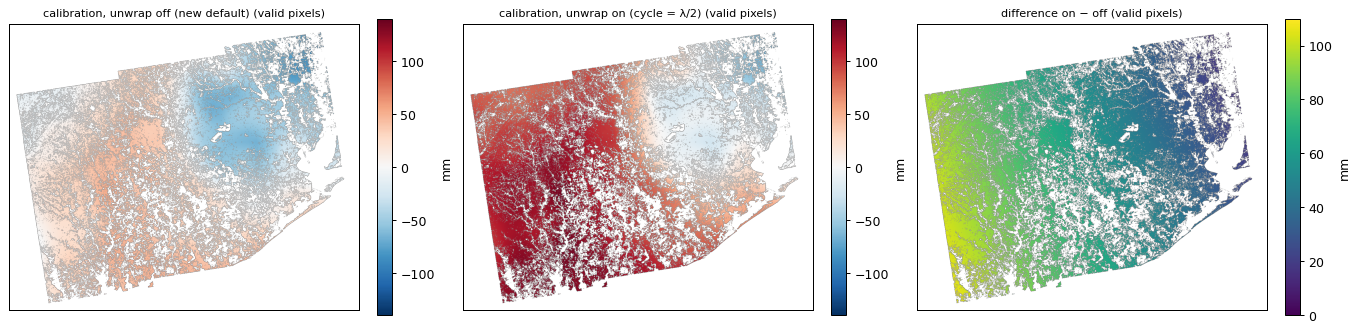

In [7]:
if RUN_FULL:
    cal = {}
    for tag in ("unwrap_on", "unwrap_off"):
        product = next((SCRATCH / f"nb01_{tag}" / "product").glob("OPERA_L4_DISP-CAL-S1_*.nc"))
        with xr.open_dataset(product, engine="h5netcdf", cache=False) as ds:
            cal[tag] = ds["calibration"].values[0].astype(np.float32)
    diff_mm = (cal["unwrap_on"] - cal["unwrap_off"]) * 1e3
    ok = valid & np.isfinite(diff_mm)                       # fit-mask pixels (section 2)
    d = diff_mm[ok]
    print(f"calibration(unwrap on, λ/2) - calibration(unwrap off) on {ok.sum():,} valid pixels:")
    print(f"  median {np.median(d):+.1f} mm, 1-99% [{np.percentile(d, 1):+.1f}, {np.percentile(d, 99):+.1f}] mm,"
          f" RMS {np.sqrt(np.mean(d**2)):.1f} mm, max |diff| {np.abs(d).max():.1f} mm")
    print(f"  spread of the difference across the frame (99% - 1%): {np.percentile(d, 99) - np.percentile(d, 1):.1f} mm"
          f" = {(np.percentile(d, 99) - np.percentile(d, 1)) / (CYCLE * 1e3):.1f} cycles")
    other = ~valid & np.isfinite(diff_mm)
    print(f"  pixels outside the fit mask: {other.sum():,}; identical in both runs (no valid pixel in their"
          f" downsampled block, fit term 0): {(diff_mm[other] == 0).sum():,}")

    def show(arr_mm):
        return np.where(valid, arr_mm, np.nan)[::8, ::8]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
    panels = [("calibration, unwrap off (new default)", show(cal["unwrap_off"] * 1e3), "RdBu_r", -140, 140),
              ("calibration, unwrap on (cycle = λ/2)", show(cal["unwrap_on"] * 1e3), "RdBu_r", -140, 140),
              ("difference on − off", show(diff_mm), "viridis", 0, 110)]
    for ax, (title, img, cmap, vmin, vmax) in zip(axes, panels):
        im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title + " (valid pixels)", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=ax, shrink=0.8, label="mm")
    plt.show()

**Reading the result.** With the option on, the `calibration` layer changes by a smooth surface worth
several cycles across the frame. Section 2 showed that the island offsets behind it form a continuous
distribution rather than multiples of λ/2, so they cannot be told apart from long-wavelength signal (ramps,
atmosphere) and nothing here indicates they are unwrapping errors: the mask-island segmentation re-levels
the field in whole cycles and the fitted surface follows. This notebook does not establish which of the two
products is closer to the truth - that needs a frame with known unwrapping errors, and a segmentation at
phase discontinuities on the Venti side. Until then `unwrap_error_correction` is `false` by default; when
it is enabled, it now uses the correct λ/2 cycle.